<a href="https://colab.research.google.com/github/Ryuta-Y/cv-practice/blob/main/tiny_video_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import importlib.util
import json
import os
import random
import shlex
import subprocess
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def in_colab() -> bool:
    try:
        import google.colab  # type: ignore  # noqa: F401

        return True
    except ImportError:
        return False


def ensure_packages(packages: dict[str, str]) -> None:
    missing_specs = [spec for mod, spec in packages.items() if importlib.util.find_spec(mod) is None]
    if not missing_specs:
        return

    pip_args = []
    for spec in missing_specs:
        pip_args.extend(shlex.split(spec))

    print("不足パッケージをインストールします:")
    for pkg in pip_args:
        print(" -", pkg)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pip_args])


def seed_everything(seed: int = 42) -> None:
    """乱数シードを固定して、結果をある程度再現しやすくする。"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    """GPU が使えるなら CUDA、なければ CPU を返す。"""
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def print_runtime_info() -> None:
    device = get_device()
    print(f"実行デバイス: {device}")
    if device.type == "cuda":
        print("GPU 名:", torch.cuda.get_device_name(0))
        print("CUDA version:", torch.version.cuda)


def get_output_dir(name: str, prefer_drive: bool = False) -> Path:
    if prefer_drive and in_colab() and Path("/content/drive/MyDrive").exists():
        root = Path("/content/drive/MyDrive/learning_guide_outputs")
    else:
        root = Path("/content/learning_guide_outputs") if in_colab() else Path("learning_guide_outputs")
    output_dir = root / name
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"出力先ディレクトリ: {output_dir}")
    return output_dir


def download_file(url: str, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists():
        print(f"既に存在するため再利用します: {output_path}")
        return output_path

    print(f"ダウンロード中: {url}")
    urllib.request.urlretrieve(url, output_path)
    return output_path


def maybe_mount_drive(do_mount: bool = False) -> None:
    if not do_mount or not in_colab():
        return

    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")


def maybe_upload_files() -> list[Path]:
    if not in_colab():
        return []

    from google.colab import files  # type: ignore

    uploaded = files.upload()
    return [Path(name) for name in uploaded.keys()]


def show_image_grid(
    images: list[np.ndarray],
    titles: list[str] | None = None,
    cols: int = 4,
    figsize=(14, 8),
    output_path: Path | None = None,
) -> None:
    """画像を格子状に並べて表示し、必要なら画像ファイルとして保存する。"""
    if not images:
        return

    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for index, image in enumerate(images, start=1):
        plt.subplot(rows, cols, index)
        plt.imshow(image)
        plt.axis("off")
        if titles and index - 1 < len(titles):
            plt.title(titles[index - 1], fontsize=10)
    plt.tight_layout()
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"画像グリッドを保存しました: {output_path}")
    plt.show()


def plot_training_curves(
    train_losses: list[float],
    val_losses: list[float],
    train_accs: list[float],
    val_accs: list[float],
    output_path: Path | None = None,
) -> None:
    """学習曲線を 2 枚並べて表示・保存する。"""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="train loss")
    plt.plot(val_losses, label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="train acc")
    plt.plot(val_accs, label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"学習曲線を保存しました: {output_path}")
    plt.show()


def plot_grouped_bar(
    labels: list[str],
    series: dict[str, list[float]],
    title: str,
    ylabel: str,
    output_path: Path | None = None,
) -> None:
    """複数手法の比較を棒グラフで表示する。"""
    if not labels or not series:
        return

    x = np.arange(len(labels))
    width = 0.8 / max(len(series), 1)

    plt.figure(figsize=(max(8, 1.8 * len(labels)), 5))
    for index, (name, values) in enumerate(series.items()):
        offset = (index - (len(series) - 1) / 2) * width
        plt.bar(x + offset, values, width=width, label=name)

    plt.xticks(x, labels, rotation=15)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"比較グラフを保存しました: {output_path}")
    plt.show()


def denormalize_image(image_tensor: torch.Tensor, mean: tuple[float, ...], std: tuple[float, ...]) -> np.ndarray:
    """正規化済みテンソルを可視化しやすい画像へ戻す。"""
    image = image_tensor.detach().cpu().clone()
    for channel, m, s in zip(image, mean, std):
        channel.mul_(s).add_(m)
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


def save_text(text: str, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(text, encoding="utf-8")
    print(f"テキストを保存しました: {output_path}")


def save_json(data: dict, output_path: Path) -> None:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"JSON を保存しました: {output_path}")


def count_parameters(model: torch.nn.Module, trainable_only: bool = False) -> int:
    """モデルのパラメータ数を数える。"""
    if trainable_only:
        return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return sum(parameter.numel() for parameter in model.parameters())


def format_seconds(seconds: float) -> str:
    minutes, sec = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours >= 1:
        return f"{int(hours)}h {int(minutes)}m {sec:.1f}s"
    if minutes >= 1:
        return f"{int(minutes)}m {sec:.1f}s"
    return f"{seconds:.2f}s"


def sample_video_frames(video_path: Path, num_frames: int, stride: int = 1) -> list[np.ndarray]:
    """
    動画から RGB フレームを等間隔に取り出す。

    stride を大きくすると、より長い時間範囲からフレームを拾える。
    """
    import cv2

    cap = cv2.VideoCapture(str(video_path))
    frames: list[np.ndarray] = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if not frames:
        raise RuntimeError(f"動画からフレームを読めませんでした: {video_path}")

    candidate_frames = frames[:: max(1, stride)]
    if len(candidate_frames) == 1:
        return [candidate_frames[0].copy() for _ in range(num_frames)]

    indices = np.linspace(0, len(candidate_frames) - 1, num=num_frames, dtype=int)
    sampled = [candidate_frames[index].copy() for index in indices]
    while len(sampled) < num_frames:
        sampled.append(sampled[-1].copy())
    return sampled


Mounted at /content/drive
出力先ディレクトリ: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune
実行デバイス: cuda
GPU 名: Tesla T4
CUDA version: 12.8


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


UCF101_subset.tar.gz:   0%|          | 0.00/171M [00:00<?, ?B/s]

既に展開済みです: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/UCF101_subset
画像グリッドを保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/sample_rate_short_grid.png


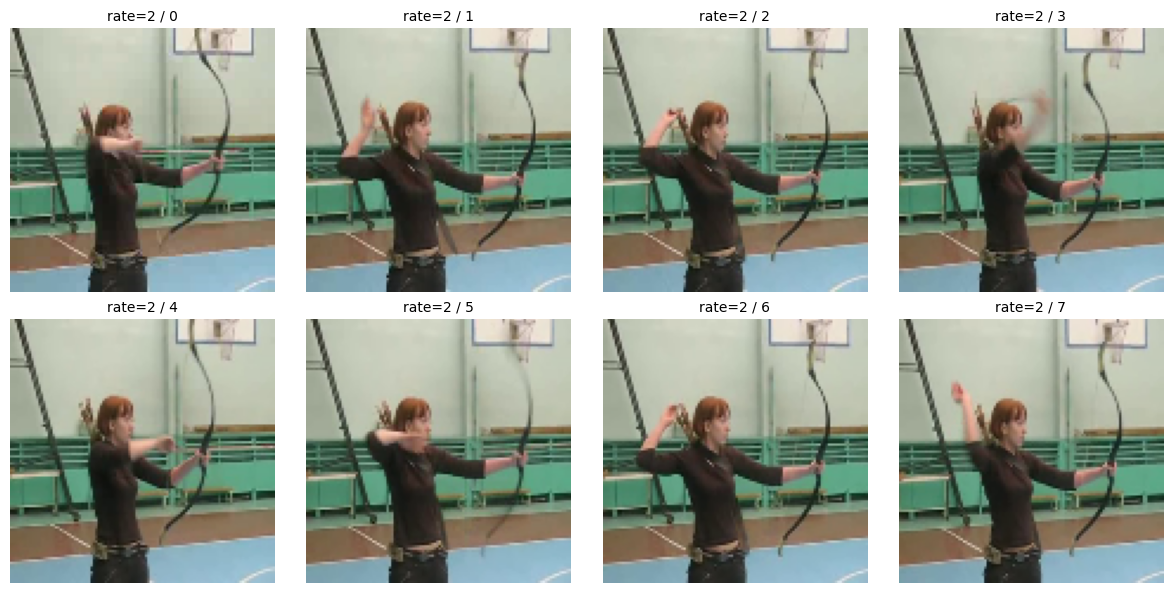

画像グリッドを保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/sample_rate_long_grid.png


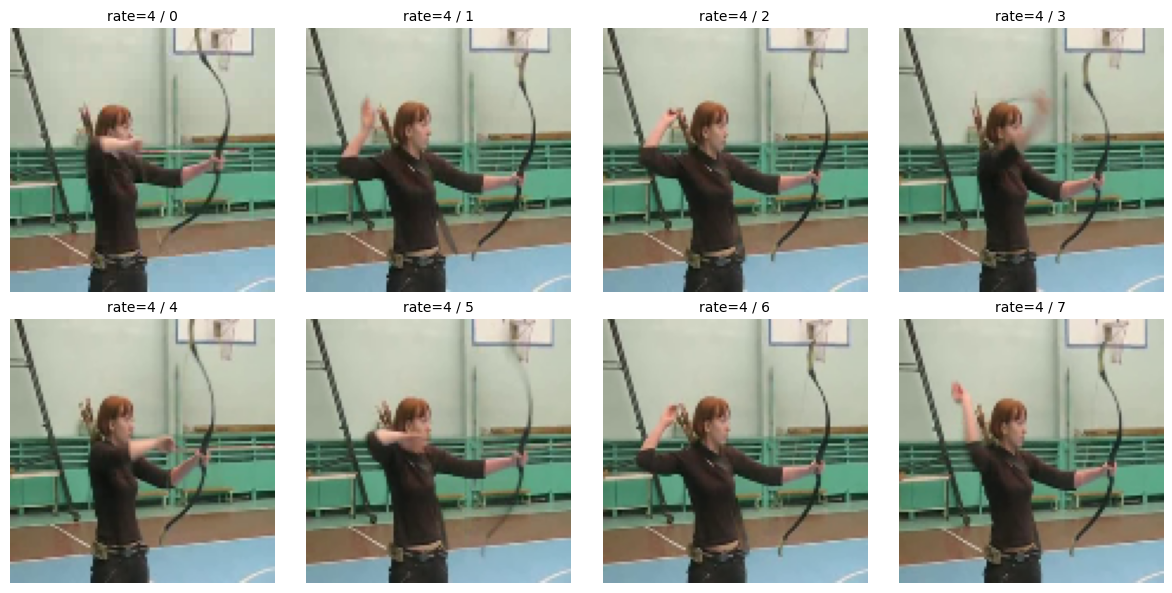

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 212MB/s]


[r3d18_rate2_e2][Epoch 1/2] train_loss=1.3515 train_acc=0.4062 val_loss=1.2864 val_acc=0.5000
[r3d18_rate2_e2][Epoch 2/2] train_loss=1.2677 train_acc=0.5000 val_loss=1.1681 val_acc=0.4167
学習曲線を保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/r3d18_rate2_e2_training_curves.png


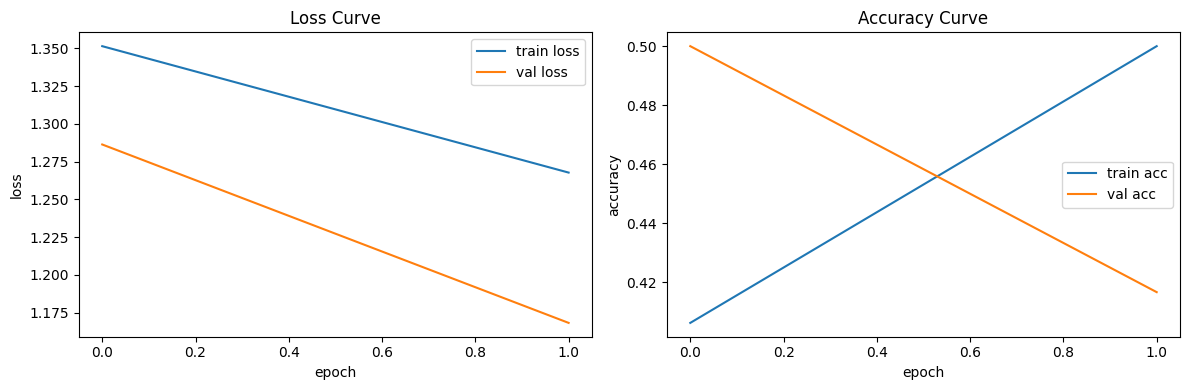

r3d18_rate2_e2 test loss=1.1399, test acc=0.5000
[r3d18_rate2_e4][Epoch 1/4] train_loss=1.4174 train_acc=0.3125 val_loss=1.2628 val_acc=0.4167
[r3d18_rate2_e4][Epoch 2/4] train_loss=1.2247 train_acc=0.5625 val_loss=1.1414 val_acc=0.4167
[r3d18_rate2_e4][Epoch 3/4] train_loss=1.1118 train_acc=0.6562 val_loss=1.0162 val_acc=0.5833
[r3d18_rate2_e4][Epoch 4/4] train_loss=1.1682 train_acc=0.6562 val_loss=0.9439 val_acc=0.6667
学習曲線を保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/r3d18_rate2_e4_training_curves.png


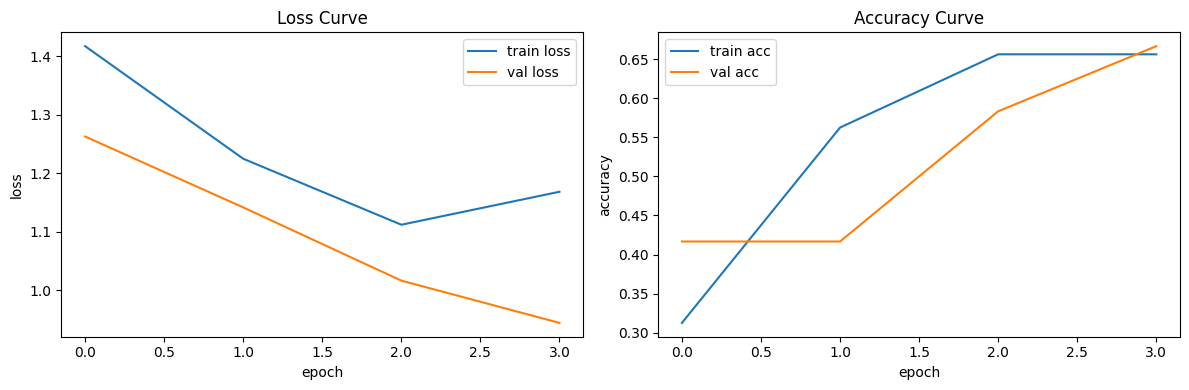

r3d18_rate2_e4 test loss=0.9096, test acc=0.8125
[r3d18_rate4_e2][Epoch 1/2] train_loss=1.5006 train_acc=0.2500 val_loss=1.5740 val_acc=0.1667
[r3d18_rate4_e2][Epoch 2/2] train_loss=1.1748 train_acc=0.6250 val_loss=1.4482 val_acc=0.2500
学習曲線を保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/r3d18_rate4_e2_training_curves.png


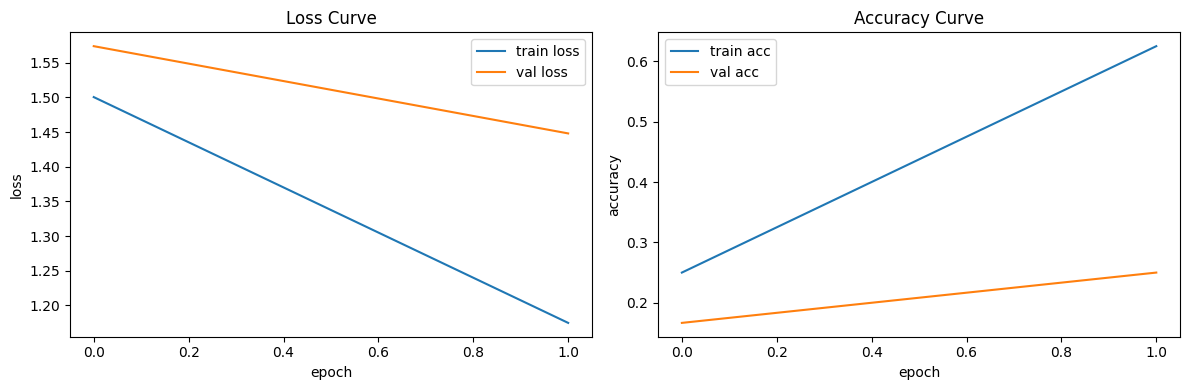

r3d18_rate4_e2 test loss=1.4031, test acc=0.1875
[r3d18_rate4_e4][Epoch 1/4] train_loss=1.5365 train_acc=0.2188 val_loss=1.2664 val_acc=0.2500
[r3d18_rate4_e4][Epoch 2/4] train_loss=1.2948 train_acc=0.3750 val_loss=1.0892 val_acc=0.5000
[r3d18_rate4_e4][Epoch 3/4] train_loss=1.2129 train_acc=0.4375 val_loss=0.9489 val_acc=0.9167
[r3d18_rate4_e4][Epoch 4/4] train_loss=1.0383 train_acc=0.7500 val_loss=0.8619 val_acc=0.8333
学習曲線を保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/r3d18_rate4_e4_training_curves.png


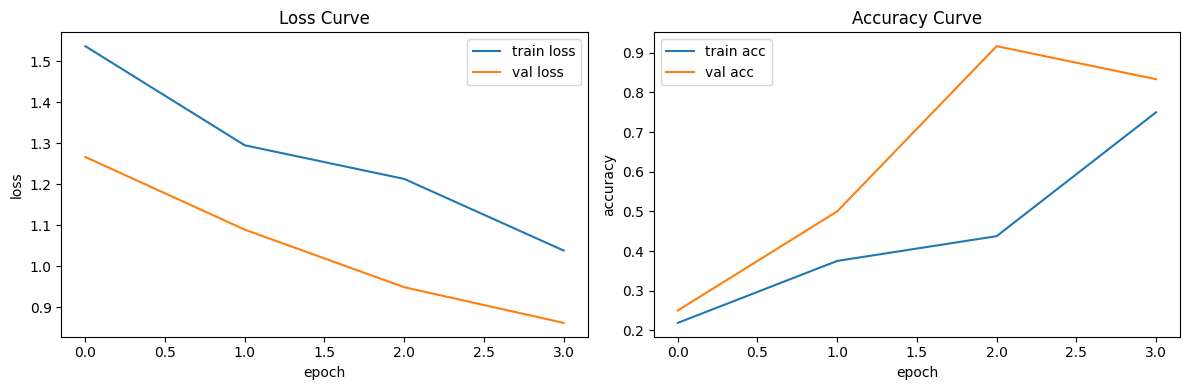

r3d18_rate4_e4 test loss=0.8518, test acc=0.8750


/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:189: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")


比較グラフを保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/sample_rate_comparison.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


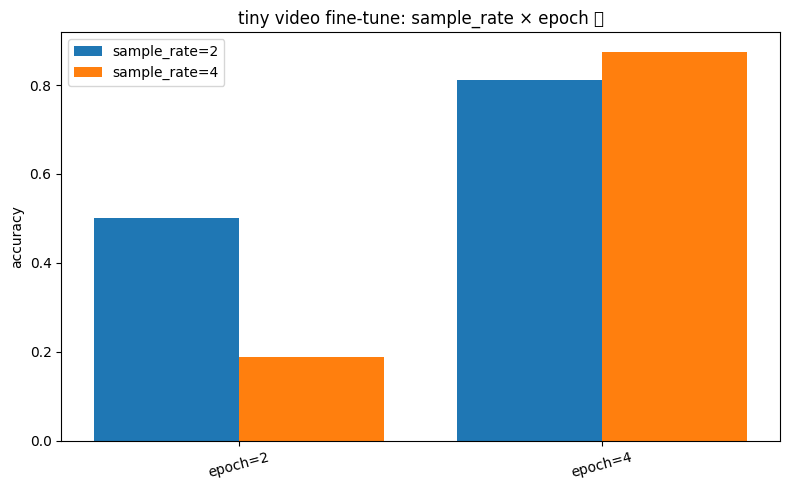

/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:189: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_15868/784126506.py:189: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_1

比較グラフを保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/sample_rate_runtime_comparison.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


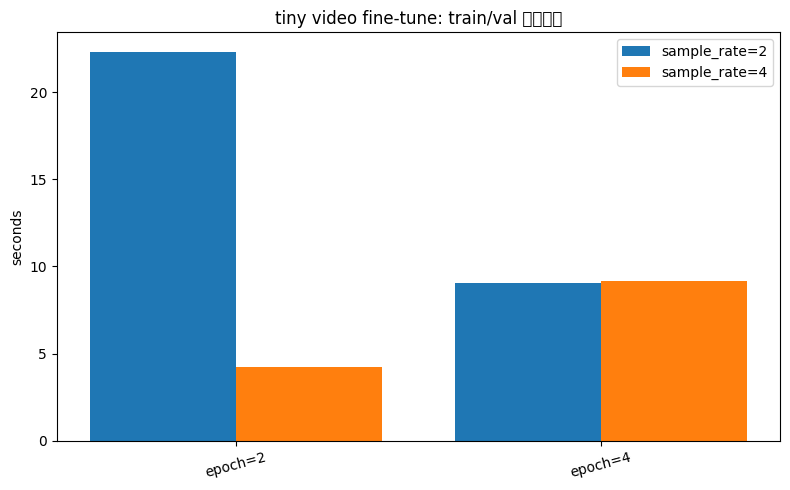

/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:187: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_15868/784126506.py:189: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_15868/784126506.py:189: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_1

比較グラフを保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/sample_rate_test_runtime_comparison.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


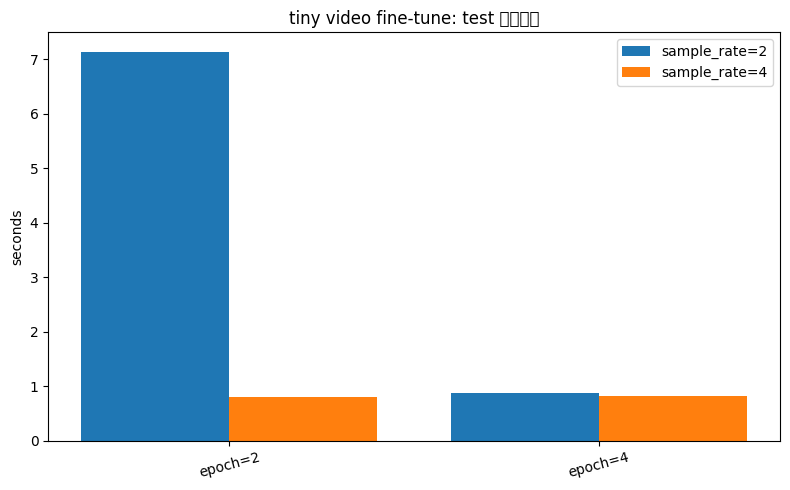

テキストを保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/summary.txt
JSON を保存しました: /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune/metrics.json


In [2]:
from __future__ import annotations

import sys
import tarfile
import time
from pathlib import Path

ensure_packages(
    {
        "cv2": "opencv-python-headless",
        "huggingface_hub": "huggingface_hub",
    }
)

import cv2
import numpy as np
import torch
from huggingface_hub import hf_hub_download
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models


# 目的
# - UCF101 subset
# - R3D-18 fine-tune
# - 観点: sample_rate

SEED = 42
BATCH_SIZE = 4
EPOCHS = 2
EPOCH_OPTIONS = [2, 4]
LEARNING_RATE = 5e-4
NUM_FRAMES = 16
IMAGE_SIZE = 112
NUM_WORKERS = 0
KINETICS_MEAN = np.array([0.43216, 0.394666, 0.37645], dtype=np.float32)
KINETICS_STD = np.array([0.22803, 0.22145, 0.216989], dtype=np.float32)
TARGET_CLASSES = ["Archery", "BaseballPitch", "Basketball", "BenchPress"]
MAX_TRAIN_PER_CLASS = 8
MAX_VAL_PER_CLASS = 3
MAX_TEST_PER_CLASS = 4
SHORT_SAMPLE_RATE = 2
LONG_SAMPLE_RATE = 4
PREVIEW_FRAME_COUNT = 8
PREVIEW_GRID_COLS = 4
PREVIEW_GRID_FIGSIZE = (12, 6)


class TinyUCFDataset(Dataset):
    """video dataset."""

    def __init__(self, samples, label2id, sample_rate: int) -> None:
        self.samples = samples
        self.label2id = label2id
        self.sample_rate = sample_rate

    def __len__(self) -> int:
        return len(self.samples)

    def _load_video(self, video_path: Path) -> torch.Tensor:
        cap = cv2.VideoCapture(str(video_path))
        frames = []
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        cap.release()
        if not frames:
            raise RuntimeError(f"動画を読めませんでした: {video_path}")

        # sample_rate: 時間幅
        candidate_frames = frames[:: max(1, self.sample_rate)]
        indices = np.linspace(0, len(candidate_frames) - 1, num=min(NUM_FRAMES, len(candidate_frames)), dtype=int)
        sampled = [candidate_frames[index] for index in indices]
        while len(sampled) < NUM_FRAMES:
            sampled.append(sampled[-1].copy())

        resized_frames = []
        for frame in sampled:
            frame = cv2.resize(frame, (IMAGE_SIZE, IMAGE_SIZE))
            frame = frame.astype(np.float32) / 255.0
            frame = (frame - KINETICS_MEAN) / KINETICS_STD
            resized_frames.append(frame)

        video = np.stack(resized_frames)
        video = np.transpose(video, (3, 0, 1, 2))
        return torch.tensor(video, dtype=torch.float32)

    def __getitem__(self, index: int):
        video_path, label_name = self.samples[index]
        video = self._load_video(video_path)
        label = self.label2id[label_name]
        return video, label


def collect_subset_samples(dataset_root: Path):
    split_limits = {
        "train": MAX_TRAIN_PER_CLASS,
        "val": MAX_VAL_PER_CLASS,
        "test": MAX_TEST_PER_CLASS,
    }
    split_samples = {}
    for split_name, limit in split_limits.items():
        samples = []
        for class_name in TARGET_CLASSES:
            class_dir = dataset_root / split_name / class_name
            class_videos = sorted(class_dir.glob("*.avi"))[:limit]
            samples.extend((path, class_name) for path in class_videos)
        split_samples[split_name] = samples
    return split_samples


def run_epoch(model, loader, criterion, optimizer, device):
    """1 epoch: video train / eval."""
    start = time.perf_counter()
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    scaler = torch.amp.GradScaler("cuda") if is_train and device.type == "cuda" else None

    for videos, labels in loader:
        videos = videos.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(videos)
                loss = criterion(logits, labels)
            if is_train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += labels.size(0)

    return total_loss / total_count, total_correct / total_count, time.perf_counter() - start


def build_model(num_classes: int):
    """R3D-18 head replace."""
    model = models.video.r3d_18(weights=models.video.R3D_18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def train_experiment(name, sample_rate, num_epochs, split_samples, label2id, device, output_dir):
    train_dataset = TinyUCFDataset(split_samples["train"], label2id, sample_rate=sample_rate)
    val_dataset = TinyUCFDataset(split_samples["val"], label2id, sample_rate=sample_rate)
    test_dataset = TinyUCFDataset(split_samples["test"], label2id, sample_rate=sample_rate)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = build_model(num_classes=len(label2id)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.fc.parameters(), lr=LEARNING_RATE)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    epoch_times = []
    for epoch in range(num_epochs):
        train_loss, train_acc, train_epoch_seconds = run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_epoch_seconds = run_epoch(model, val_loader, criterion, optimizer=None, device=device)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        epoch_times.append(
            {
                "epoch": epoch + 1,
                "train_seconds": train_epoch_seconds,
                "val_seconds": val_epoch_seconds,
                "total_seconds": train_epoch_seconds + val_epoch_seconds,
            }
        )
        print(
            f"[{name}][Epoch {epoch + 1}/{num_epochs}] "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    plot_training_curves(
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        output_path=output_dir / f"{name}_training_curves.png",
    )

    test_loss, test_acc, test_seconds = run_epoch(model, test_loader, criterion, optimizer=None, device=device)
    torch.save(model.state_dict(), output_dir / f"{name}.pt")
    print(f"{name} test loss={test_loss:.4f}, test acc={test_acc:.4f}")
    return {
        "name": name,
        "sample_rate": sample_rate,
        "num_epochs": num_epochs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_seconds": test_seconds,
        "epoch_times": epoch_times,
        "total_parameters": count_parameters(model),
        "trainable_parameters": count_parameters(model, trainable_only=True),
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
        "test_samples": len(test_dataset),
    }


def extract_dataset(output_dir: Path) -> Path:
    """dataset download / extract."""
    dataset_file = hf_hub_download(
        repo_id="sayakpaul/ucf101-subset",
        filename="UCF101_subset.tar.gz",
        repo_type="dataset",
    )
    dataset_root = output_dir / "UCF101_subset"
    if dataset_root.exists():
        print(f"既に展開済みです: {dataset_root}")
        return dataset_root

    with tarfile.open(dataset_file) as tar:
        tar.extractall(path=output_dir)
    return dataset_root


def unnormalize_frame(frame: np.ndarray) -> np.ndarray:
    """unnormalize."""
    frame = (frame * KINETICS_STD) + KINETICS_MEAN
    frame = np.clip(frame, 0.0, 1.0)
    return frame


def main() -> None:
    overall_start = time.perf_counter()
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    maybe_mount_drive(do_mount=True)
    output_dir = get_output_dir("09_tiny_video_finetune", prefer_drive=True)
    print_runtime_info()
    device = get_device()

    dataset_root = extract_dataset(output_dir)
    split_samples = collect_subset_samples(dataset_root)
    label2id = {label: index for index, label in enumerate(TARGET_CLASSES)}

    preview_dataset_short = TinyUCFDataset(split_samples["train"][:1], label2id, sample_rate=SHORT_SAMPLE_RATE)
    preview_dataset_long = TinyUCFDataset(split_samples["train"][:1], label2id, sample_rate=LONG_SAMPLE_RATE)
    preview_short, _ = preview_dataset_short[0]
    preview_long, _ = preview_dataset_long[0]

    short_images = [
        unnormalize_frame(preview_short[:, i].permute(1, 2, 0).numpy()) for i in range(PREVIEW_FRAME_COUNT)
    ]
    long_images = [
        unnormalize_frame(preview_long[:, i].permute(1, 2, 0).numpy()) for i in range(PREVIEW_FRAME_COUNT)
    ]
    show_image_grid(
        short_images,
        [f"rate={SHORT_SAMPLE_RATE} / {i}" for i in range(PREVIEW_FRAME_COUNT)],
        cols=PREVIEW_GRID_COLS,
        figsize=PREVIEW_GRID_FIGSIZE,
        output_path=output_dir / "sample_rate_short_grid.png",
    )
    show_image_grid(
        long_images,
        [f"rate={LONG_SAMPLE_RATE} / {i}" for i in range(PREVIEW_FRAME_COUNT)],
        cols=PREVIEW_GRID_COLS,
        figsize=PREVIEW_GRID_FIGSIZE,
        output_path=output_dir / "sample_rate_long_grid.png",
    )

    results = []
    for num_epochs in EPOCH_OPTIONS:
        results.append(
            train_experiment(
                f"r3d18_rate{SHORT_SAMPLE_RATE}_e{num_epochs}",
                SHORT_SAMPLE_RATE,
                num_epochs,
                split_samples,
                label2id,
                device,
                output_dir,
            )
        )
    for num_epochs in EPOCH_OPTIONS:
        results.append(
            train_experiment(
                f"r3d18_rate{LONG_SAMPLE_RATE}_e{num_epochs}",
                LONG_SAMPLE_RATE,
                num_epochs,
                split_samples,
                label2id,
                device,
                output_dir,
            )
        )

    epoch_labels = [f"epoch={num_epochs}" for num_epochs in EPOCH_OPTIONS]
    plot_grouped_bar(
        labels=epoch_labels,
        series={
            f"sample_rate={SHORT_SAMPLE_RATE}": [
                next(
                    result["test_acc"]
                    for result in results
                    if result["name"] == f"r3d18_rate{SHORT_SAMPLE_RATE}_e{num_epochs}"
                )
                for num_epochs in EPOCH_OPTIONS
            ],
            f"sample_rate={LONG_SAMPLE_RATE}": [
                next(
                    result["test_acc"]
                    for result in results
                    if result["name"] == f"r3d18_rate{LONG_SAMPLE_RATE}_e{num_epochs}"
                )
                for num_epochs in EPOCH_OPTIONS
            ],
        },
        title="tiny video fine-tune: sample_rate × epoch 数",
        ylabel="accuracy",
        output_path=output_dir / "sample_rate_comparison.png",
    )
    plot_grouped_bar(
        labels=epoch_labels,
        series={
            f"sample_rate={SHORT_SAMPLE_RATE}": [
                sum(
                    item["total_seconds"]
                    for item in next(
                        result["epoch_times"]
                        for result in results
                        if result["name"] == f"r3d18_rate{SHORT_SAMPLE_RATE}_e{num_epochs}"
                    )
                )
                for num_epochs in EPOCH_OPTIONS
            ],
            f"sample_rate={LONG_SAMPLE_RATE}": [
                sum(
                    item["total_seconds"]
                    for item in next(
                        result["epoch_times"]
                        for result in results
                        if result["name"] == f"r3d18_rate{LONG_SAMPLE_RATE}_e{num_epochs}"
                    )
                )
                for num_epochs in EPOCH_OPTIONS
            ],
        },
        title="tiny video fine-tune: train/val 時間比較",
        ylabel="seconds",
        output_path=output_dir / "sample_rate_runtime_comparison.png",
    )
    plot_grouped_bar(
        labels=epoch_labels,
        series={
            f"sample_rate={SHORT_SAMPLE_RATE}": [
                next(
                    result["test_seconds"]
                    for result in results
                    if result["name"] == f"r3d18_rate{SHORT_SAMPLE_RATE}_e{num_epochs}"
                )
                for num_epochs in EPOCH_OPTIONS
            ],
            f"sample_rate={LONG_SAMPLE_RATE}": [
                next(
                    result["test_seconds"]
                    for result in results
                    if result["name"] == f"r3d18_rate{LONG_SAMPLE_RATE}_e{num_epochs}"
                )
                for num_epochs in EPOCH_OPTIONS
            ],
        },
        title="tiny video fine-tune: test 時間比較",
        ylabel="seconds",
        output_path=output_dir / "sample_rate_test_runtime_comparison.png",
    )

    overall_seconds = time.perf_counter() - overall_start
    summary_lines = [
        "Tiny video fine-tune summary",
        f"EPOCH_OPTIONS: {EPOCH_OPTIONS}",
        f"Notebook total runtime: {format_seconds(overall_seconds)}",
        "sample_rate=2 は短めの時間窓、sample_rate=4 は長めの時間窓を見る設定です。",
        "どちらが有利かは、行動が短いか長いか、ポーズ中心か物体変化中心かで変わります。",
    ]
    for result in results:
        summary_lines.extend(
            [
                f"{result['name']} test accuracy: {result['test_acc']:.4f}",
                f"{result['name']} total train+val time: {format_seconds(sum(item['total_seconds'] for item in result['epoch_times']))}",
                f"{result['name']} test time: {format_seconds(result['test_seconds'])}",
            ]
        )
    save_text("\n".join(summary_lines), output_dir / "summary.txt")
    save_json(
        {
            "config": {
                "seed": SEED,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "epoch_options": EPOCH_OPTIONS,
                "learning_rate": LEARNING_RATE,
                "num_frames": NUM_FRAMES,
                "image_size": IMAGE_SIZE,
                "num_workers": NUM_WORKERS,
                "target_classes": TARGET_CLASSES,
                "max_train_per_class": MAX_TRAIN_PER_CLASS,
                "max_val_per_class": MAX_VAL_PER_CLASS,
                "max_test_per_class": MAX_TEST_PER_CLASS,
                "short_sample_rate": SHORT_SAMPLE_RATE,
                "long_sample_rate": LONG_SAMPLE_RATE,
                "preview_frame_count": PREVIEW_FRAME_COUNT,
                "preview_grid_cols": PREVIEW_GRID_COLS,
            },
            "dataset": {
                split_name: len(samples) for split_name, samples in split_samples.items()
            },
            "models": results,
            "runtime": {
                "overall_seconds": overall_seconds,
            },
        },
        output_dir / "metrics.json",
    )


main()


output_dir = /content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune

===== summary.txt =====

Tiny video fine-tune summary
EPOCH_OPTIONS: [2, 4]
Notebook total runtime: 2m 15.6s
sample_rate=2 は短めの時間窓、sample_rate=4 は長めの時間窓を見る設定です。
どちらが有利かは、行動が短いか長いか、ポーズ中心か物体変化中心かで変わります。
r3d18_rate2_e2 test accuracy: 0.5000
r3d18_rate2_e2 total train+val time: 22.34s
r3d18_rate2_e2 test time: 7.14s
r3d18_rate2_e4 test accuracy: 0.8125
r3d18_rate2_e4 total train+val time: 9.02s
r3d18_rate2_e4 test time: 0.88s
r3d18_rate4_e2 test accuracy: 0.1875
r3d18_rate4_e2 total train+val time: 4.24s
r3d18_rate4_e2 test time: 0.81s
r3d18_rate4_e4 test accuracy: 0.8750
r3d18_rate4_e4 total train+val time: 9.14s
r3d18_rate4_e4 test time: 0.82s

===== metrics.json (先頭 1500 文字) =====

{
  "config": {
    "seed": 42,
    "batch_size": 4,
    "epochs": 2,
    "epoch_options": [
      2,
      4
    ],
    "learning_rate": 0.0005,
    "num_frames": 16,
    "image_size": 112,
    "num_workers": 0,
    "target_cl

### r3d18_rate2_e2_training_curves.png

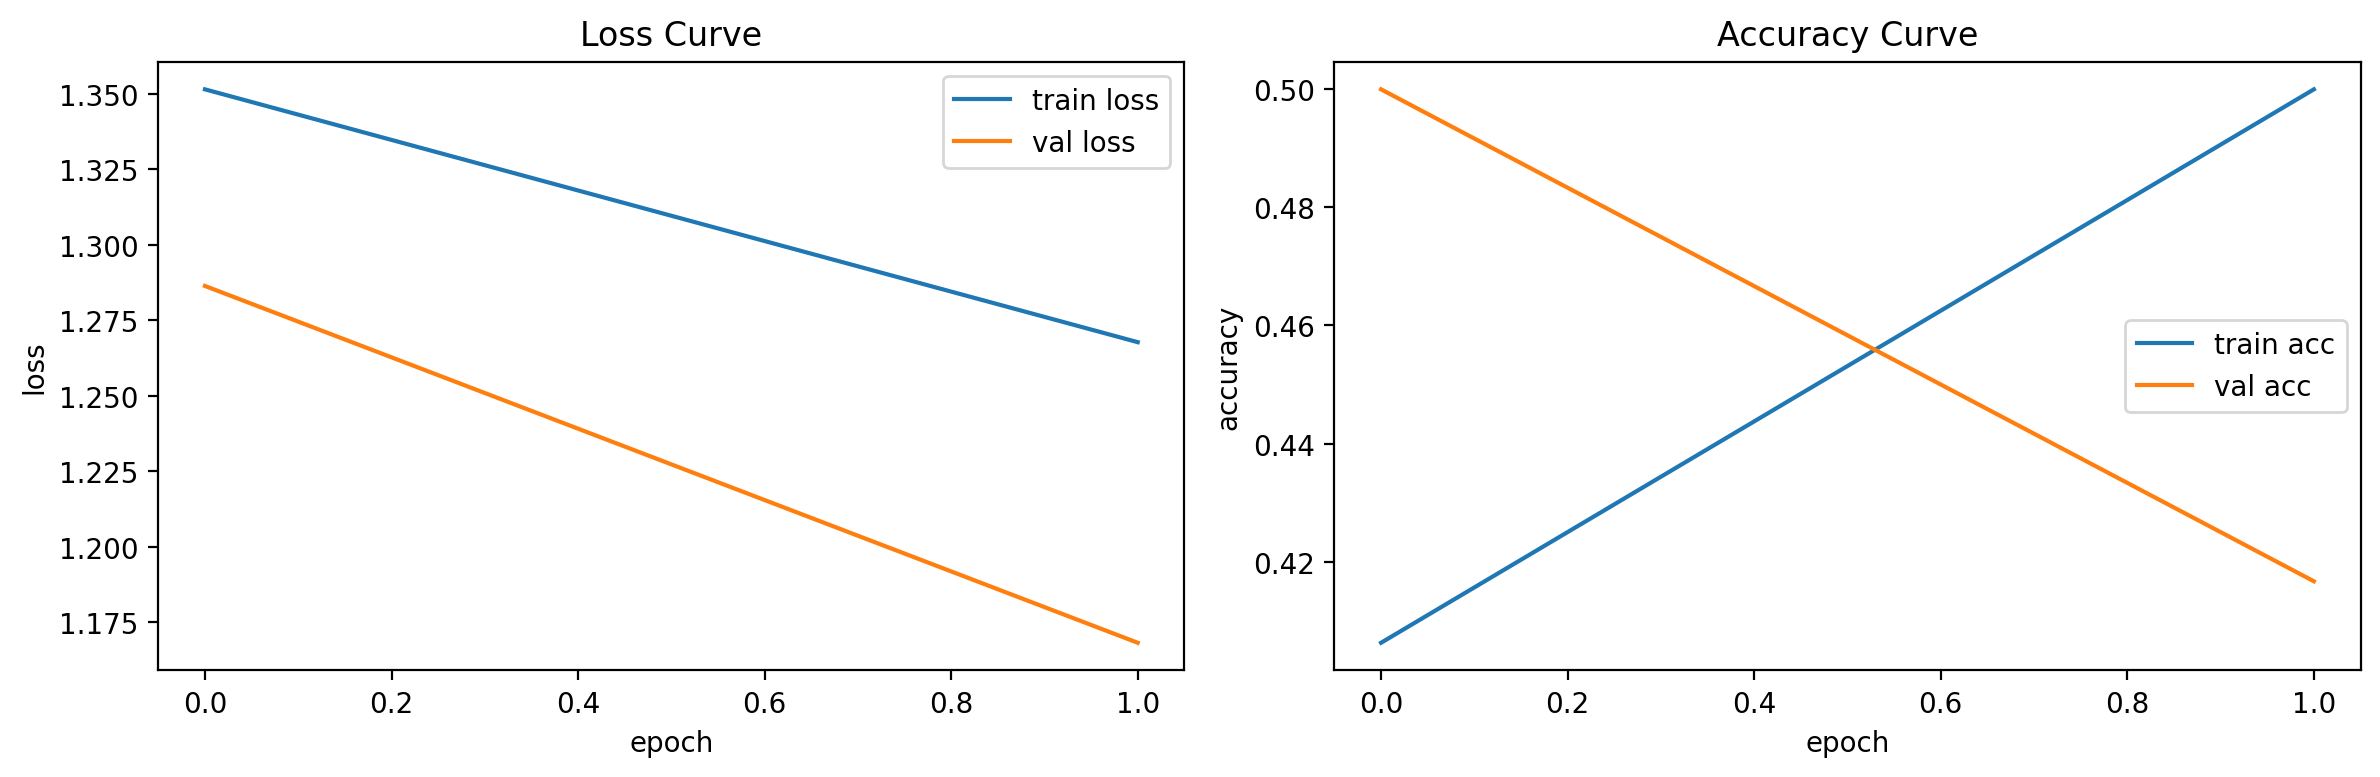

### r3d18_rate2_e4_training_curves.png

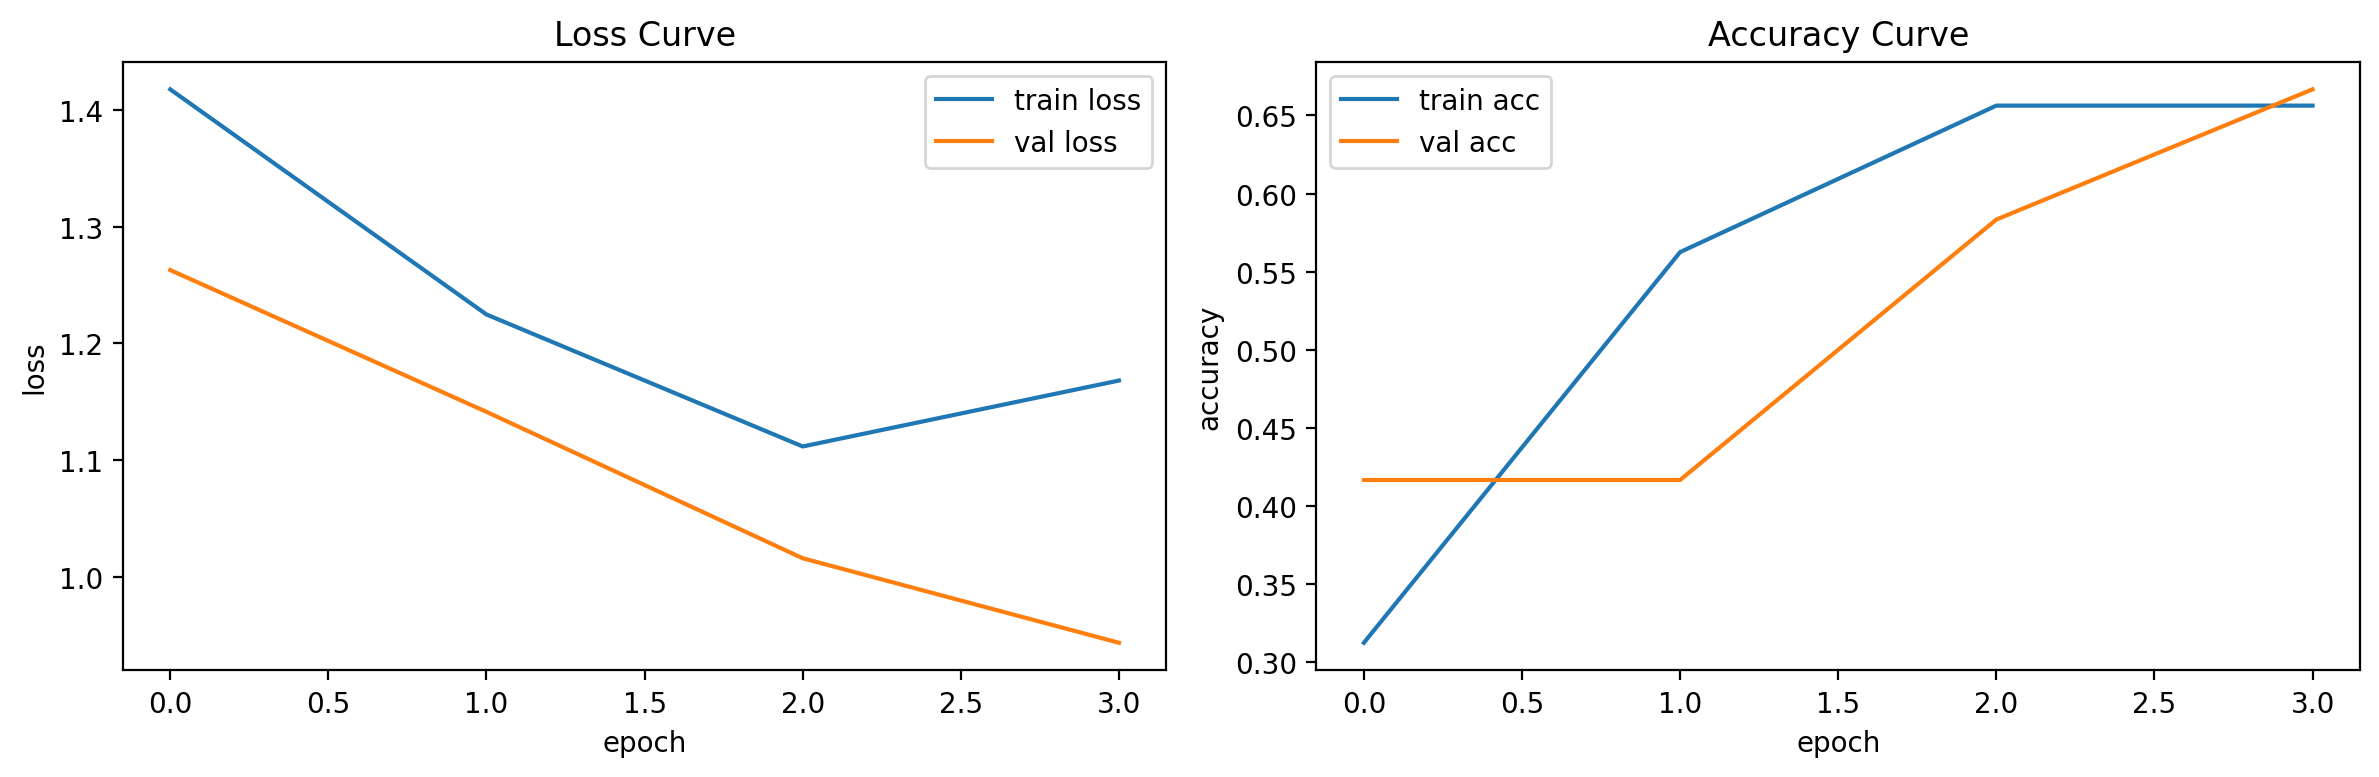

### r3d18_rate4_e2_training_curves.png

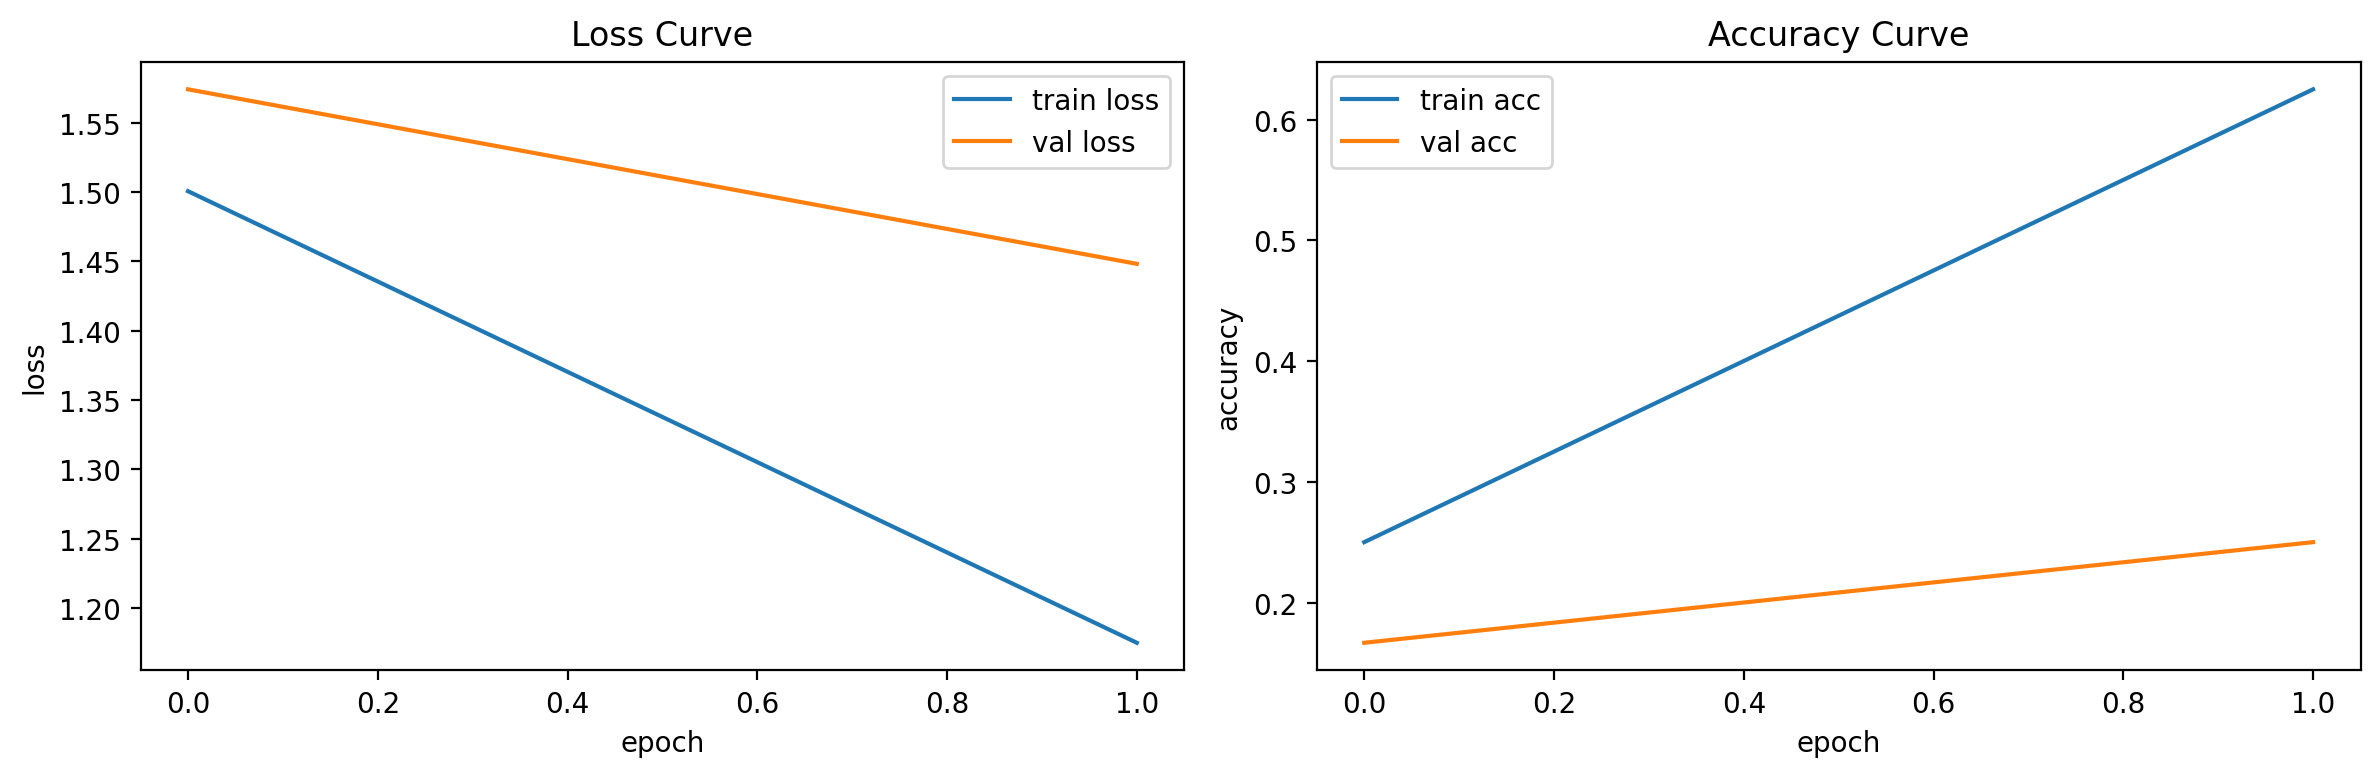

### r3d18_rate4_e4_training_curves.png

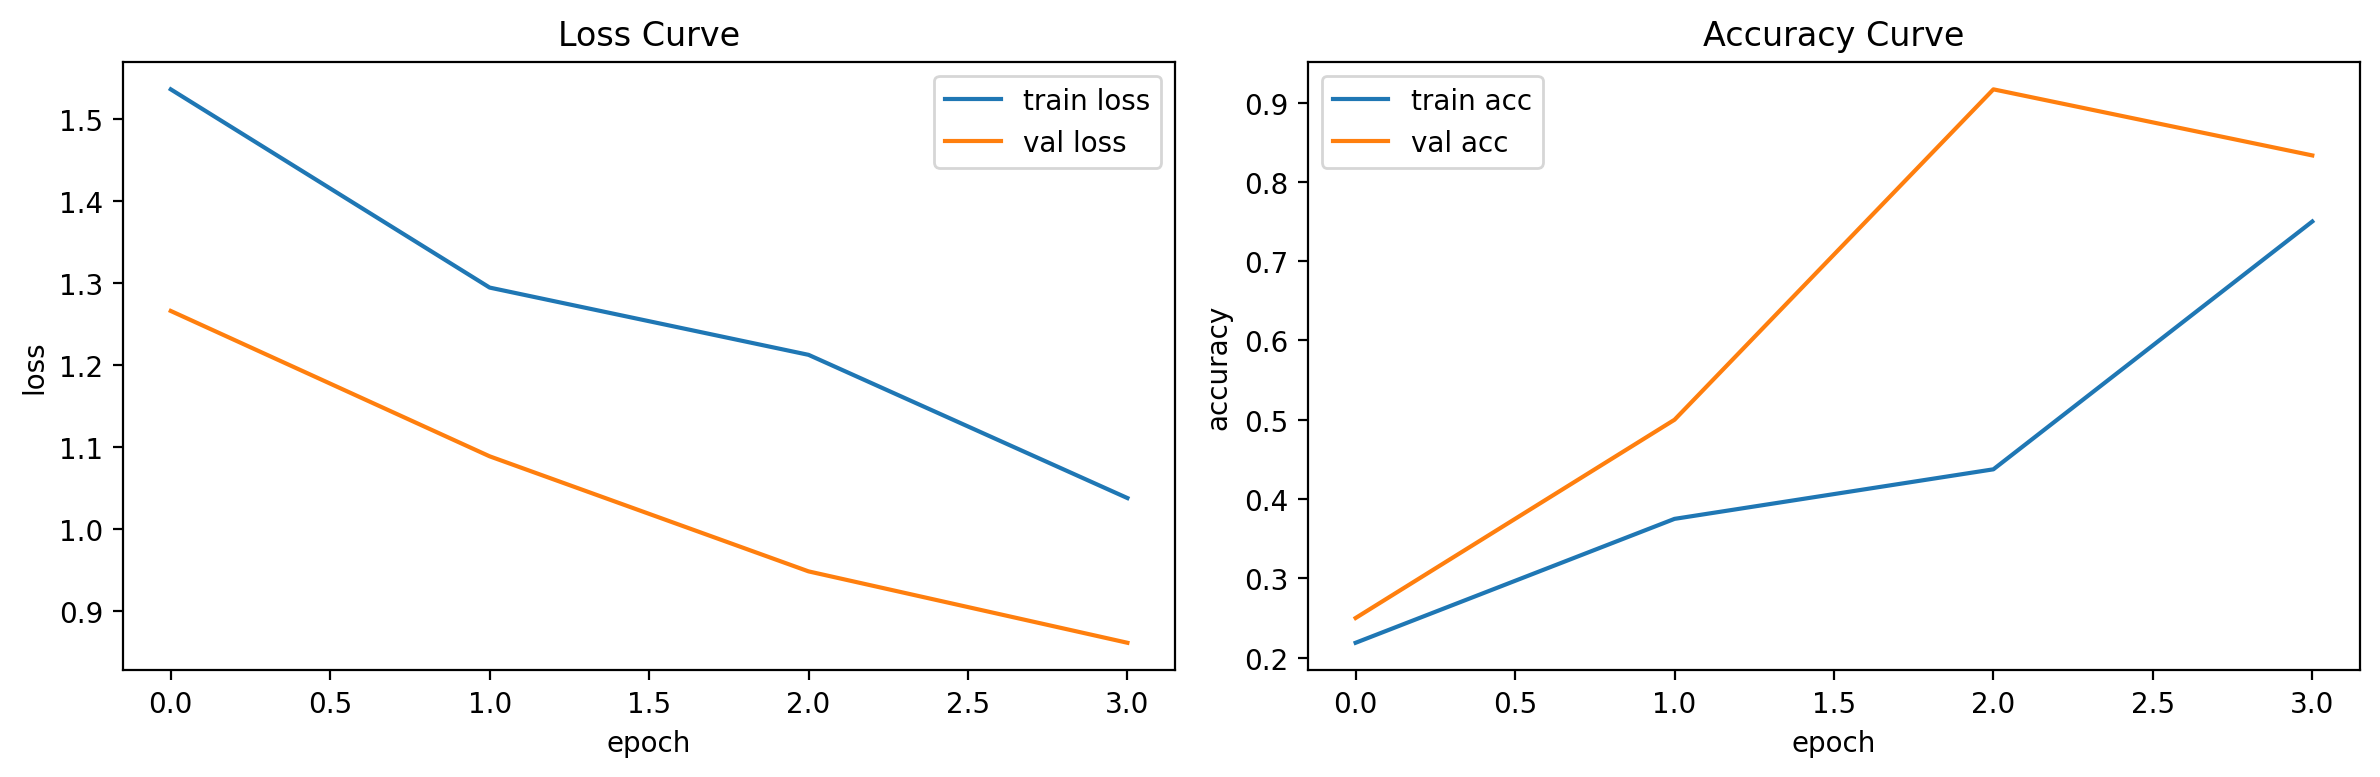

### sample_rate_comparison.png

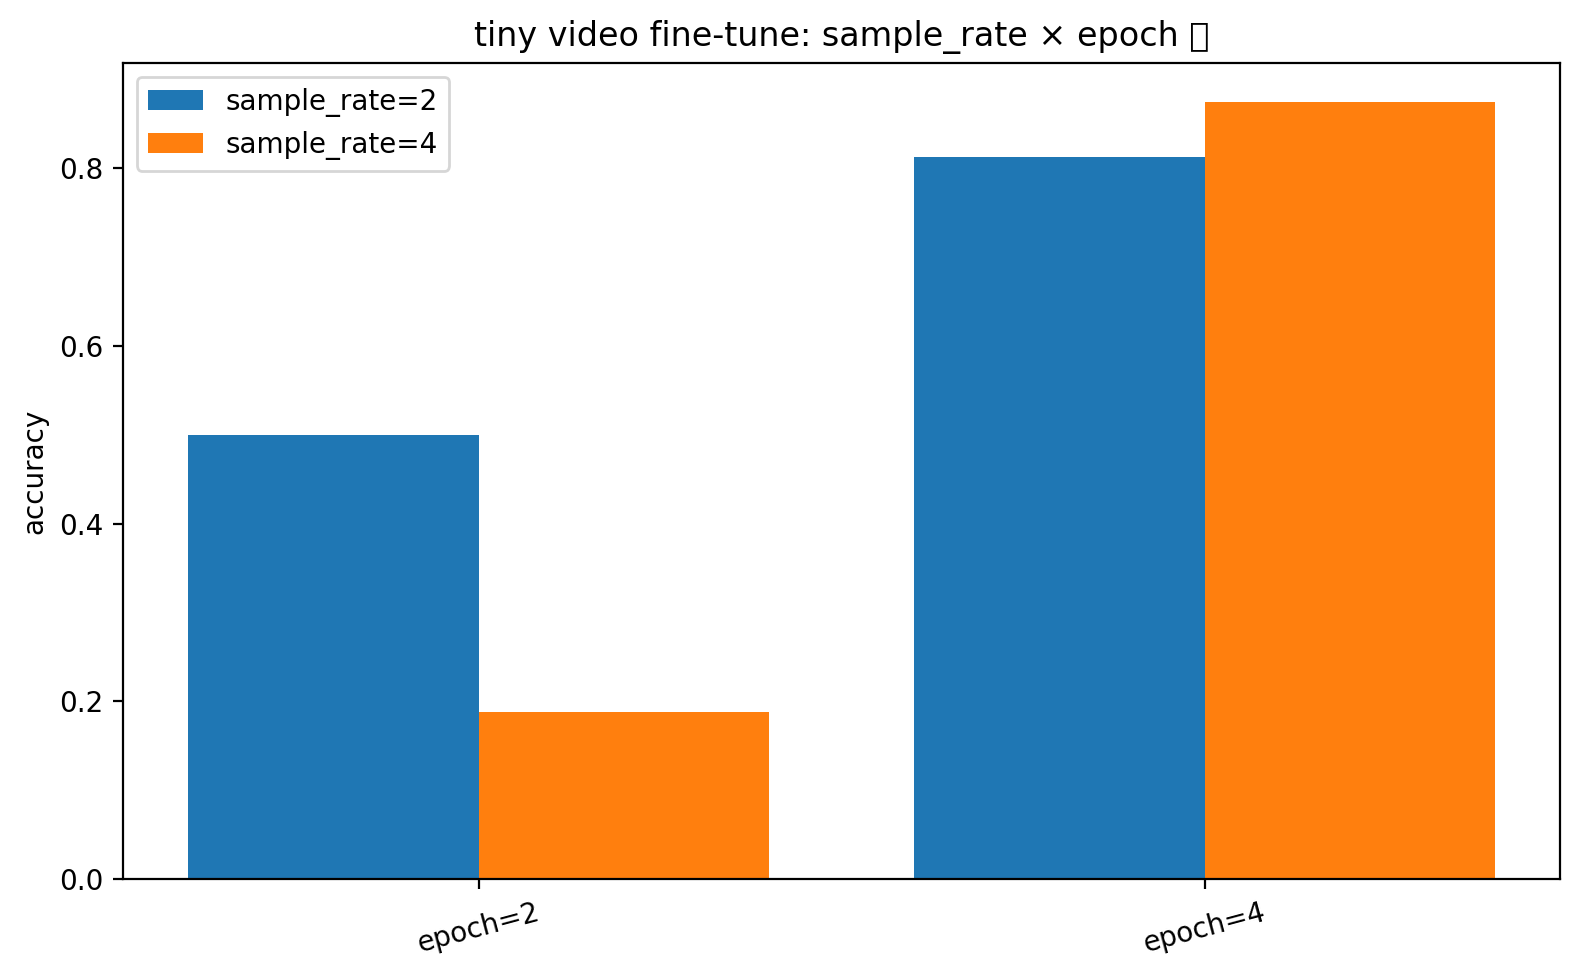

### sample_rate_long_grid.png

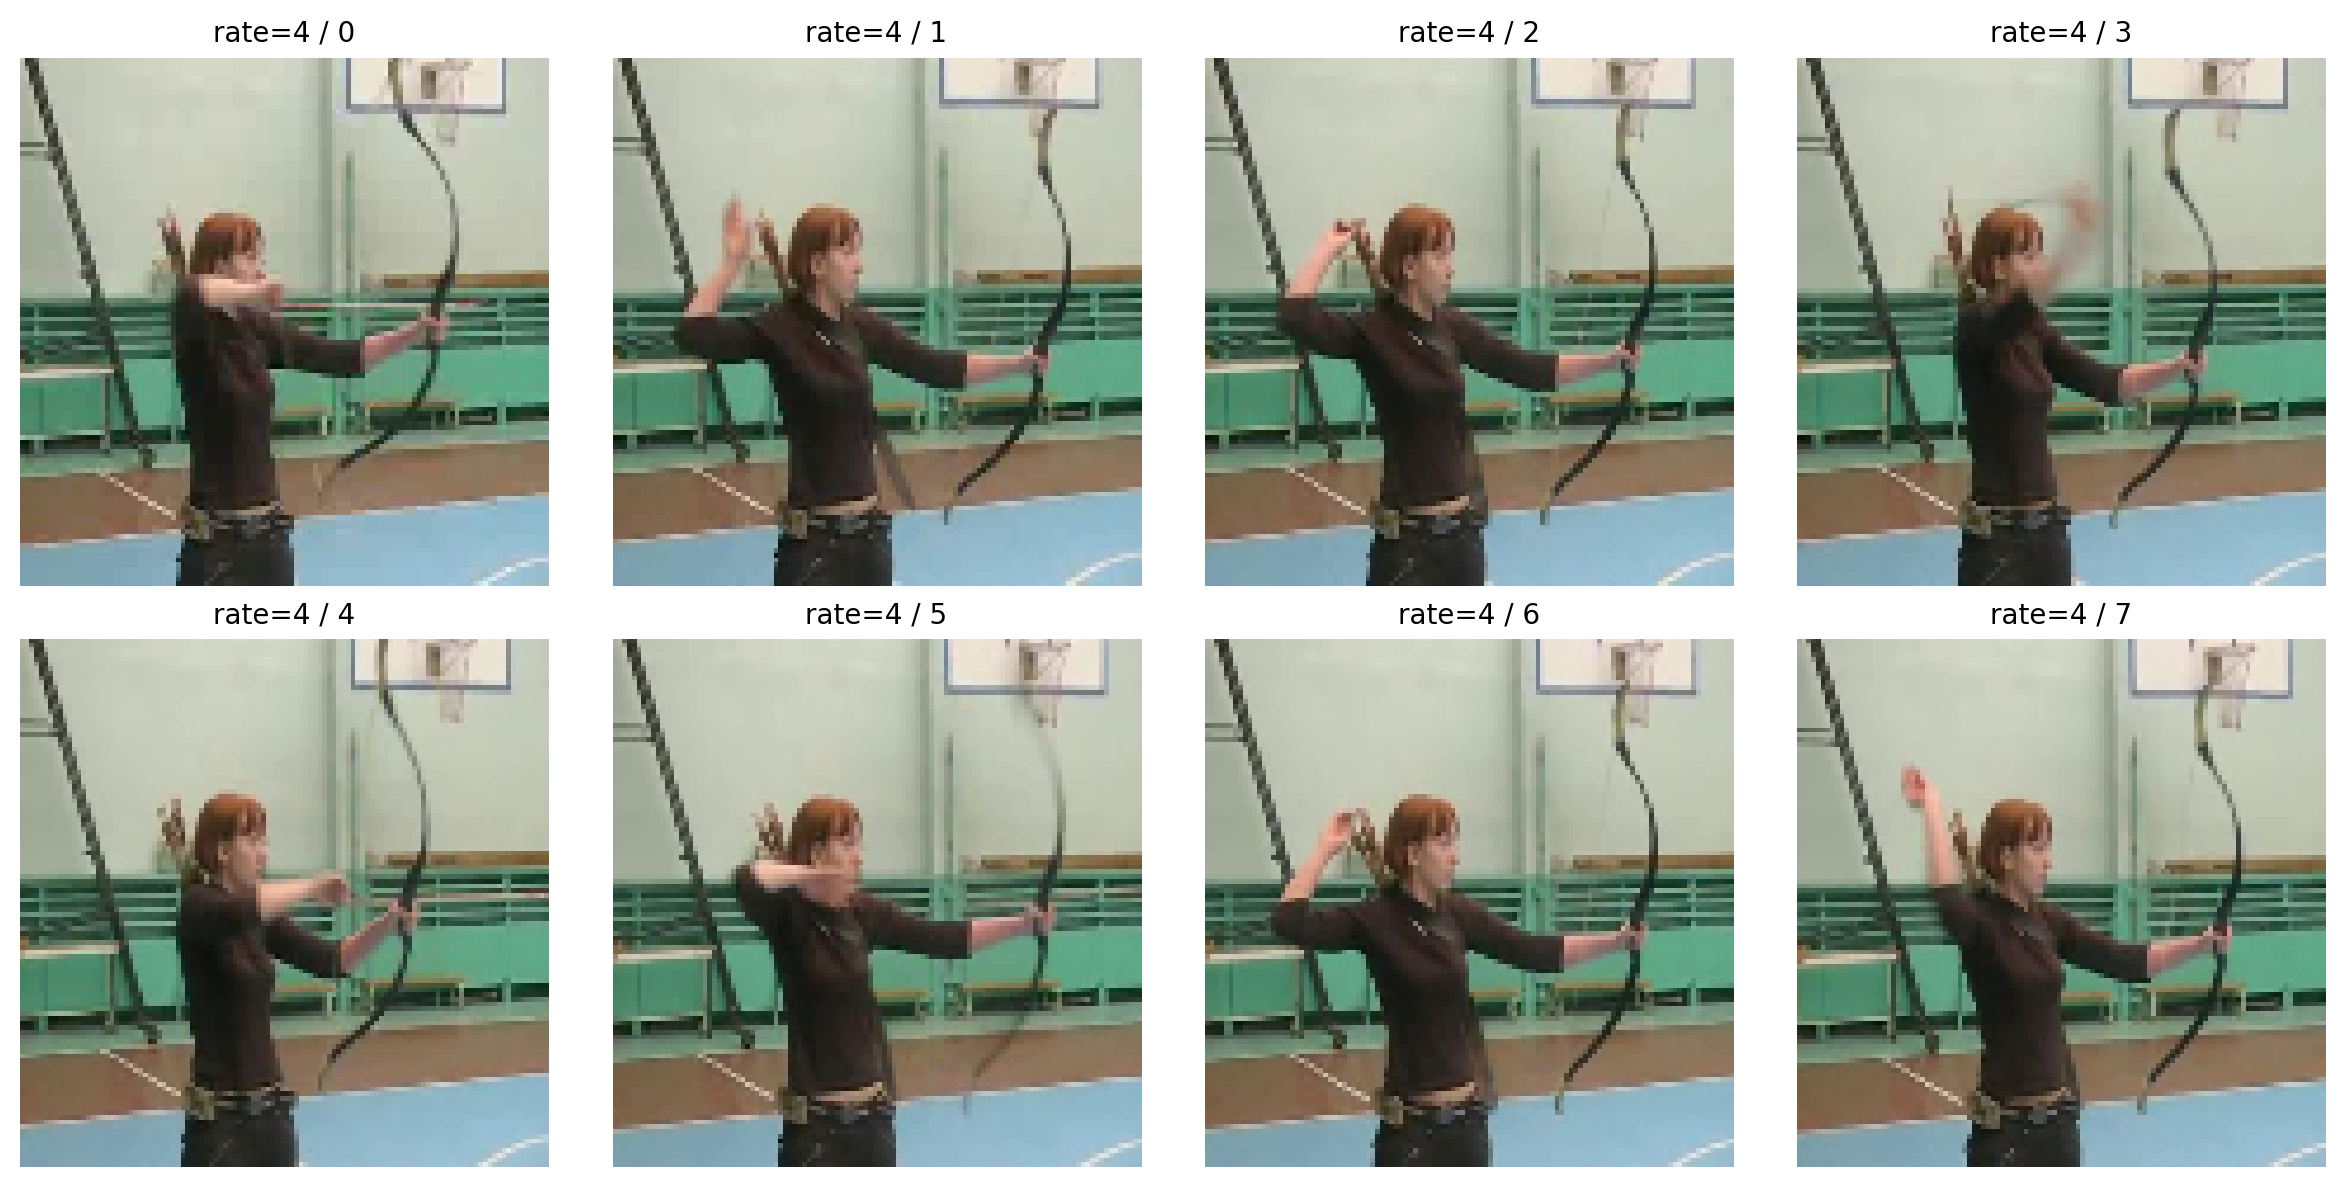

### sample_rate_runtime_comparison.png

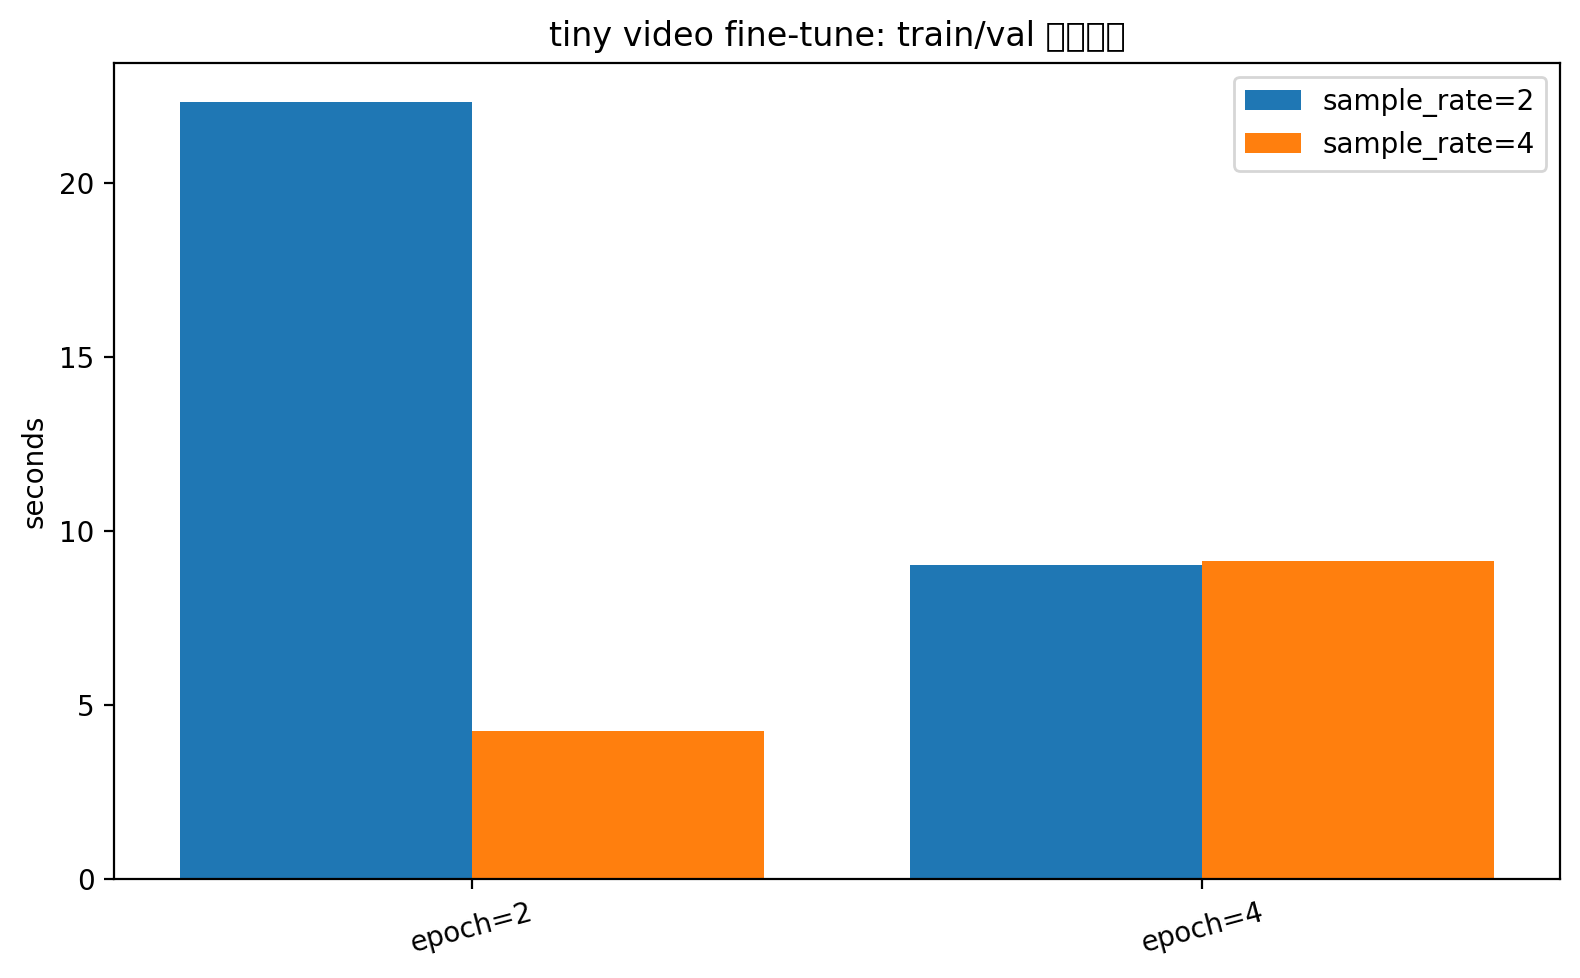

### sample_rate_short_grid.png

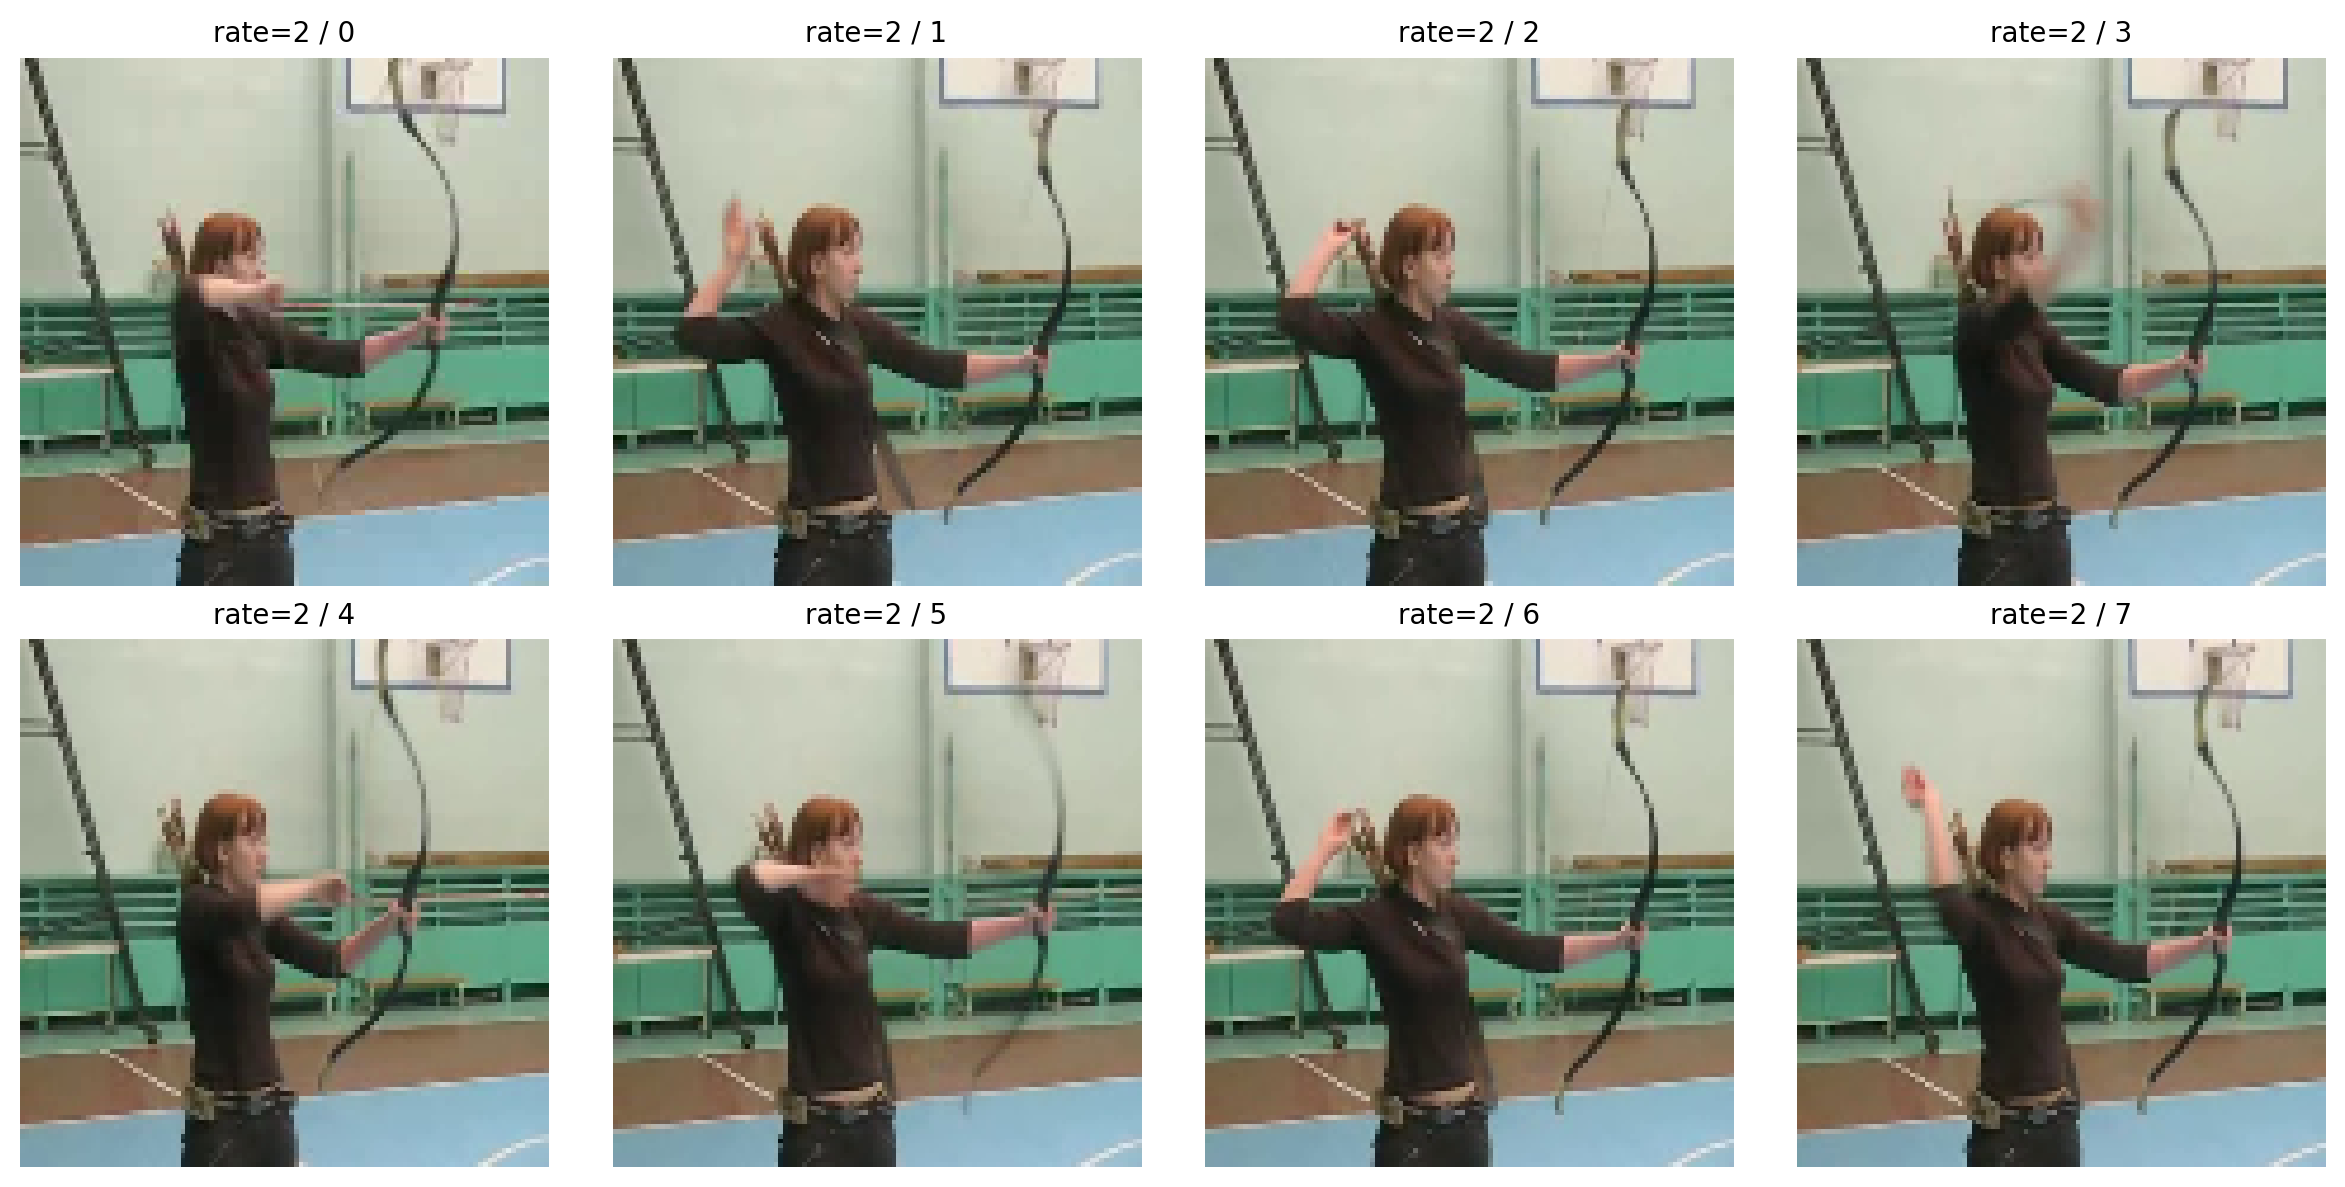

### sample_rate_test_runtime_comparison.png

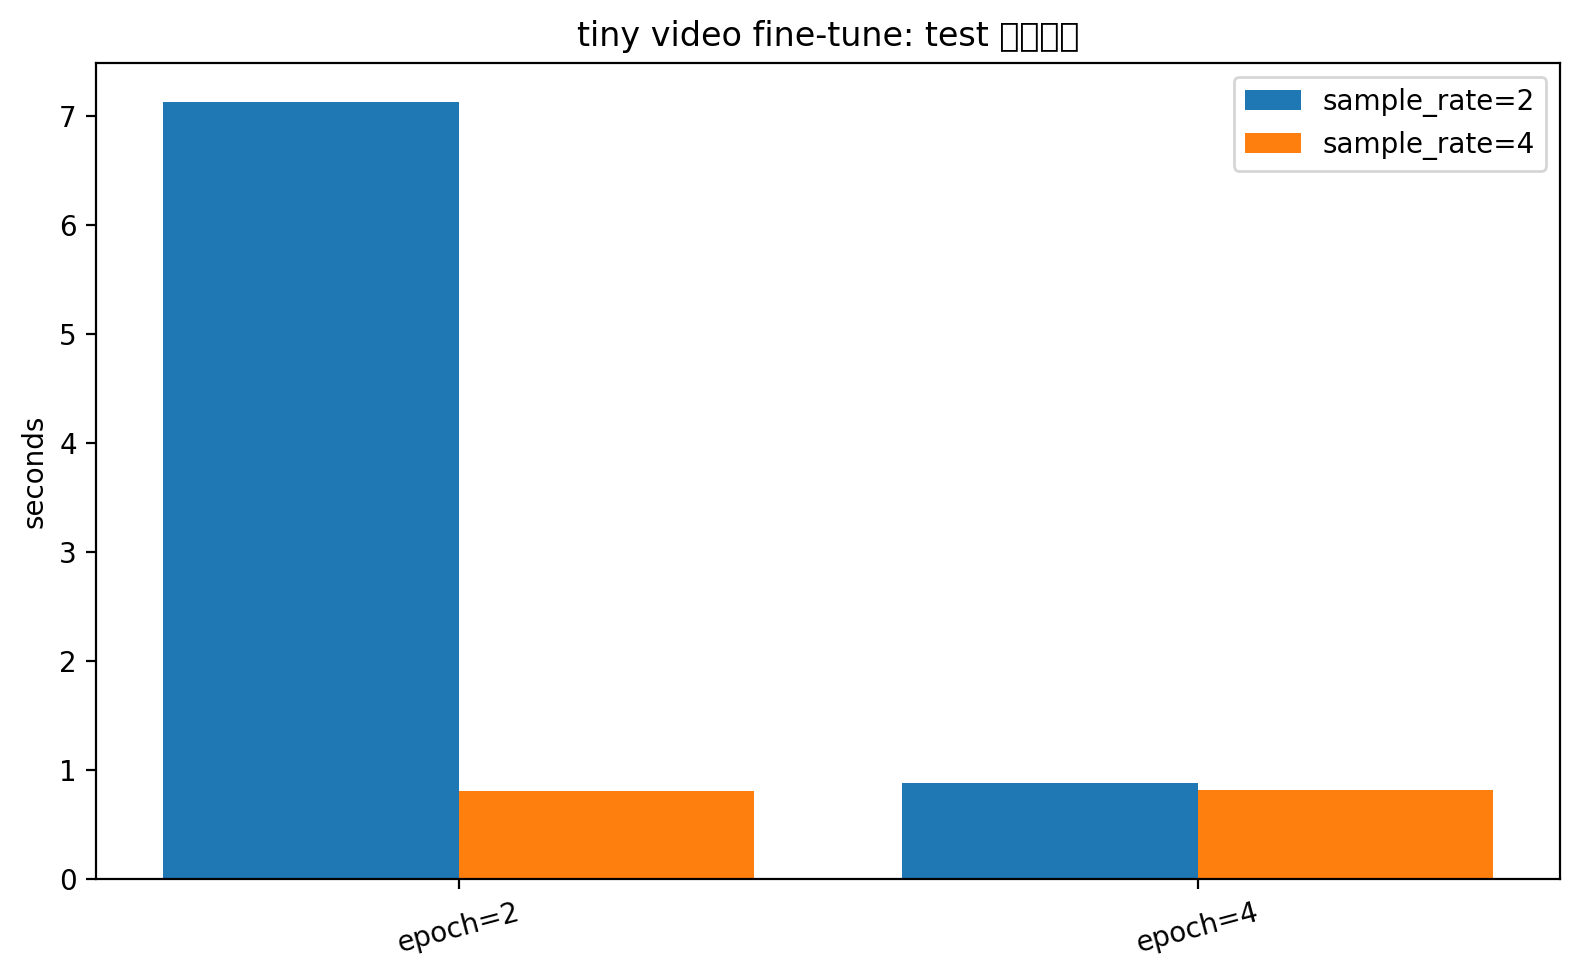

In [3]:
from pathlib import Path
from IPython.display import Image, Video, display, Markdown

out_dir = None
for candidate in [Path('/content/drive/MyDrive/learning_guide_outputs/09_tiny_video_finetune'), Path('/content/learning_guide_outputs/09_tiny_video_finetune')]:
    if candidate.exists():
        out_dir = candidate
        break

if out_dir is None:
    print('出力ディレクトリが見つかりませんでした。先に上の実験セルを実行してください。')
else:
    print(f'output_dir = {out_dir}')
    summary_path = out_dir / 'summary.txt'
    metrics_path = out_dir / 'metrics.json'
    if summary_path.exists():
        print('\n===== summary.txt =====\n')
        print(summary_path.read_text(encoding='utf-8'))
    if metrics_path.exists():
        print('\n===== metrics.json (先頭 1500 文字) =====\n')
        text = metrics_path.read_text(encoding='utf-8')
        print(text[:1500] + ('...' if len(text) > 1500 else ''))
    for png in sorted(out_dir.glob('*.png')):
        display(Markdown(f'### {png.name}'))
        display(Image(filename=str(png)))
    for mp4 in sorted(out_dir.glob('*.mp4')):
        display(Markdown(f'### {mp4.name}'))
        display(Video(str(mp4), embed=True, width=720))
